In [6]:
# STEP 1: Import required libraries for data analysis and visualization

import pandas as pd        # For data manipulation
import numpy as np         # For numerical operations
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns      # For advanced visualization

# Set a simple plotting style
plt.style.use("default")

In [10]:
# STEP 2: Load dataset from CSV file

df = pd.read_csv(r"C:\Users\RISHI\Desktop\USDN\USND\notebooks\Database.csv")

# Display first 5 rows
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [11]:
# STEP 3: Validate Time Data

# Convert Declaration Date to datetime
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')

# Check missing or invalid dates
df['Declaration Date'].isnull().sum()

np.int64(0)

In [12]:
# STEP 4: Extract year and month from Declaration Date

df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

# Check new columns
df[['Declaration Date','year','month']].head()

,Declaration Date,year,month
0,1953-05-02,1953,5
1,1953-05-15,1953,5
2,1953-05-29,1953,5
3,1953-06-02,1953,6
4,1953-06-06,1953,6


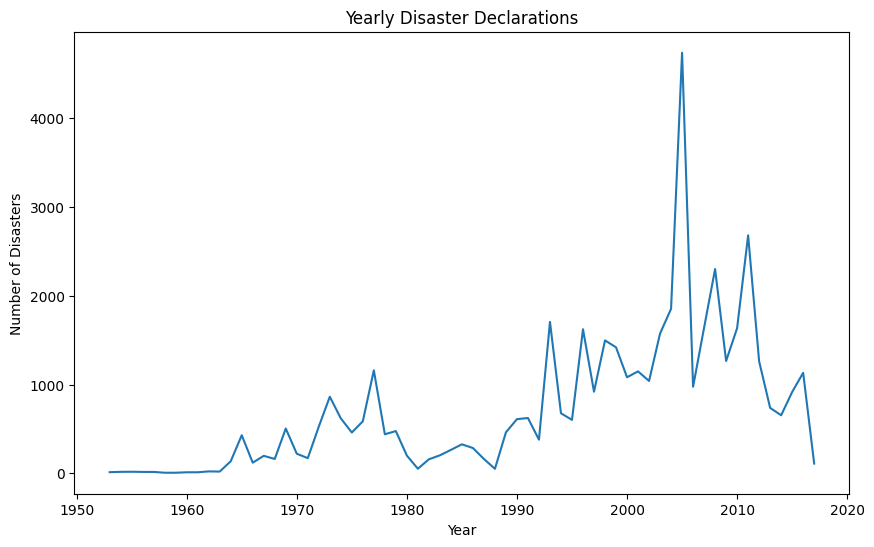

In [13]:
# STEP 5: Yearly Trend Analysis

yearly = df.groupby('year').size()

plt.figure(figsize=(10,6))

yearly.plot()

plt.title("Yearly Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

<Figure size 1400x800 with 0 Axes>

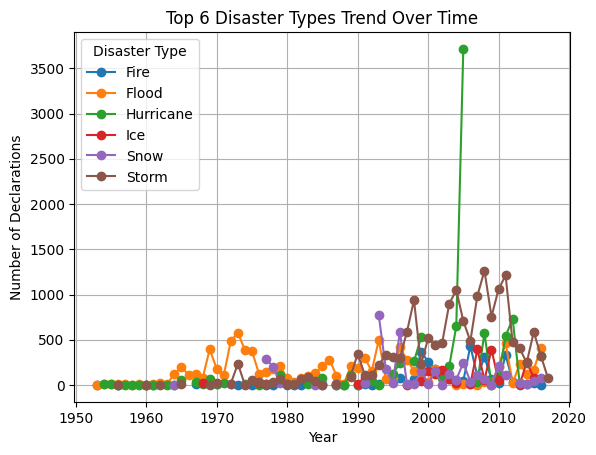

In [14]:
# STEP 6: Disaster Type Trend

top_types = df['Disaster Type'].value_counts().head(6).index

filtered_df = df[df['Disaster Type'].isin(top_types)]

incident_trend = (
    filtered_df
    .groupby(['year','Disaster Type'])
    .size()
    .unstack()
)

plt.figure(figsize=(14,8))

incident_trend.plot(marker='o')

plt.title("Top 6 Disaster Types Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")

plt.grid(True)

plt.legend(title="Disaster Type")

plt.show()

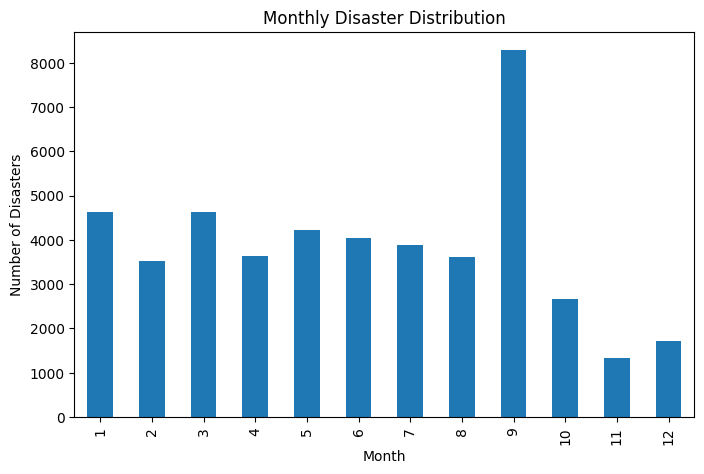

In [15]:
# STEP 7: Monthly Seasonality

monthly = df.groupby('month').size()

plt.figure(figsize=(8,5))

monthly.plot(kind='bar')

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

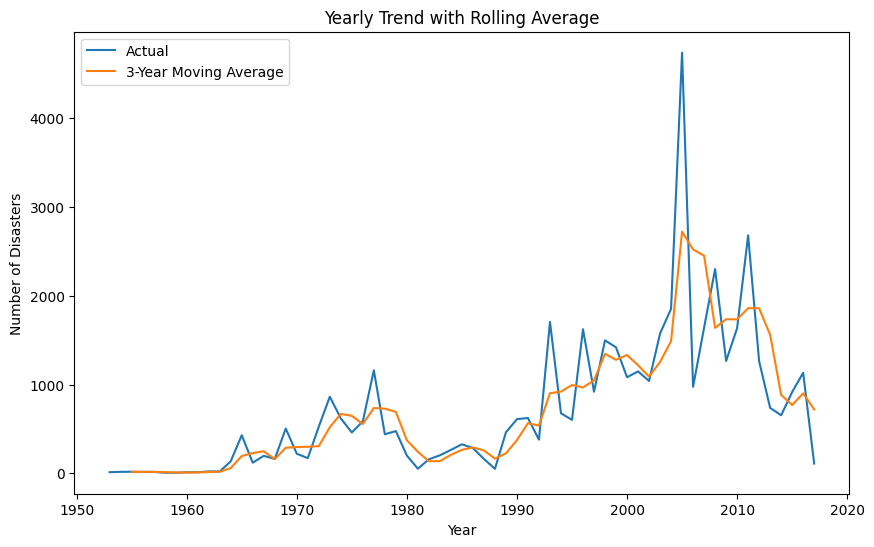

In [16]:
# STEP 8: Rolling Average

rolling_avg = yearly.rolling(window=3).mean()

plt.figure(figsize=(10,6))

yearly.plot(label="Actual")
rolling_avg.plot(label="3-Year Moving Average")

plt.title("Yearly Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.legend()

plt.show()

In [17]:
# STEP 9: Growth Rate (Year-over-Year Percentage Change)

# Calculate yearly growth rate of disaster declarations
# pct_change() computes the percentage change between current year and previous year
# Multiply by 100 to convert it into percentage

growth_rate = yearly.pct_change() * 100

# Display first few values
growth_rate.head()

year
1953          NaN
1954    30.769231
1955     5.882353
1956   -11.111111
1957     0.000000
dtype: float64

In [18]:
# STEP 10: Peak Detection (Top 5 Years)

# Sort the yearly disaster counts in descending order
# and select the top 5 years with the highest number of disasters

top_years = yearly.sort_values(ascending=False).head()

# Display the top 5 peak disaster years
top_years

year
2005    4736
2011    2680
2008    2300
2004    1853
1993    1705
dtype: int64